In [1]:
!pip install ultralytics -q

from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
print("✅ Setup Complete!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Setup Complete!


# Day 21: Anomaly Detection in Videos

## Key New Concepts Learned Today

**Note 1: What is Anomaly Detection?**
- Finding unusual events or objects that are **different from normal**.
- Examples:
  - Person walking in restricted area
  - Unusual behavior (fighting, falling)
  - Abnormal objects (fire, smoke, abandoned bag)

**Note 2: Our Approach (Advanced)**
- Use normal detection + tracking
- Define "normal" patterns
- Flag anything unusual as anomaly

**Note 3: Real-world Applications**
- Security cameras
- Factory quality control
- Traffic accident detection
- Elderly care monitoring



In [2]:
# Load model
model = YOLO("yolo11s.pt")

def detect_anomalies(video_path, normal_classes=['person', 'car', 'bus']):
    cap = cv2.VideoCapture(video_path)
    anomalies = []
    frame_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1
        results = model(frame, conf=0.3, verbose=False)

        for result in results:
            for box in result.boxes:
                cls_name = result.names[int(box.cls)]

                if cls_name not in normal_classes:
                    anomalies.append({
                        "frame": frame_count,
                        "class": cls_name,
                        "confidence": float(box.conf)
                    })
                    print(f"⚠️ Anomaly Detected: {cls_name} at frame {frame_count}")

    cap.release()
    print(f"\nTotal Anomalies Detected: {len(anomalies)}")
    return anomalies


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 594.7ms
Speed: 16.5ms preprocess, 594.7ms inference, 39.3ms postprocess per image at shape (1, 3, 640, 480)


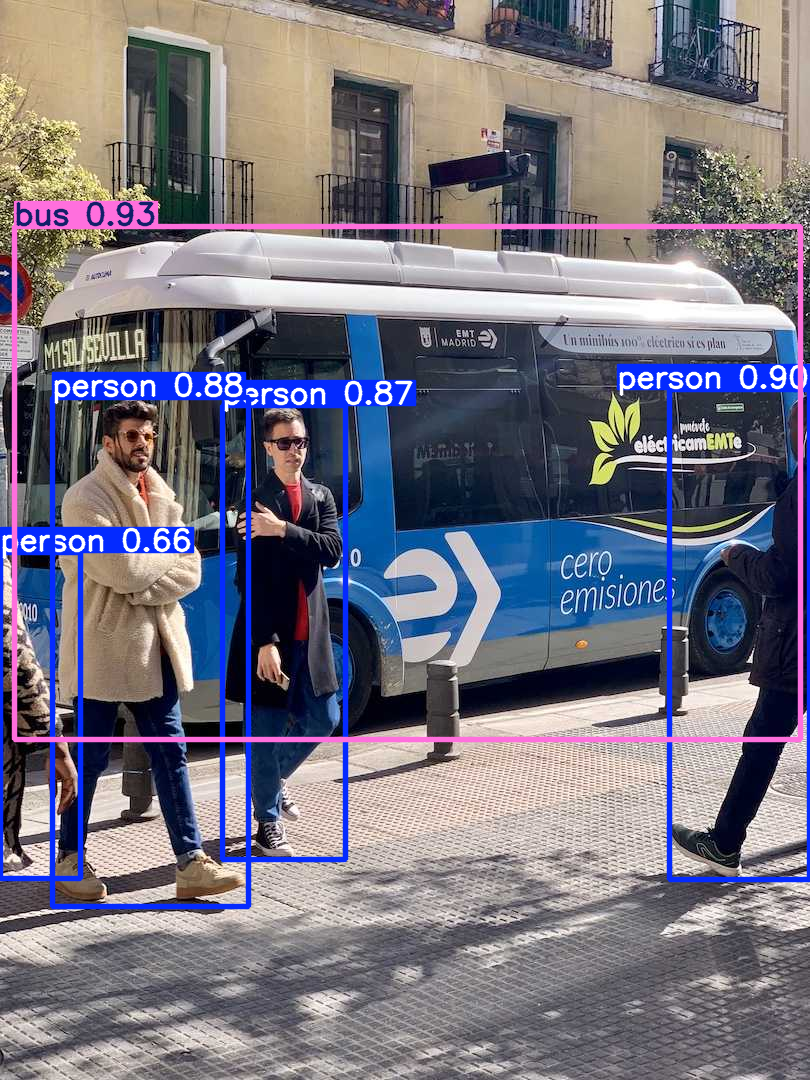

Run the function on a video to detect anomalies in motion.


In [3]:
# Test on single image
results = model("https://ultralytics.com/images/bus.jpg", conf=0.3)
results[0].show()

print("Run the function on a video to detect anomalies in motion.")